In [36]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from collections import Counter
from sklearn import metrics 
%matplotlib inline

### prepare the data 

In [27]:
df=pd.read_csv("./heart.csv")
# df.drop_duplicates(inplace=True)


In [28]:
X=df.drop("target",axis=1)
y=df["target"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state = 0)


In [29]:
#test if the data is splitted correctly
print(y_test.unique())
Counter(y_train)

[1 0]


Counter({1: 114, 0: 97})

In [30]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### linear regression

In [31]:
from sklearn.linear_model import LinearRegression
regressor=LinearRegression();
regressor.fit(X_train,y_train)

LinearRegression()

In [32]:
#the prediction
y_pred=regressor.predict(X_test);
print(y_pred)

[ 1.00432163  0.66048839  0.5999474   1.1433791   0.69481031  0.36577163
  0.61735436  0.62598775  0.65816685  0.29241896  0.27590537  0.65940201
 -0.03848237  1.0623669   0.78877189  0.20790814  0.24222037  1.18522039
  0.89484216 -0.1721511   1.10480689  1.22040417  0.75042062  0.71348007
  0.1684799   0.31704723  0.93904749  1.03442583 -0.13473648  0.67142418
  0.44008406  0.1871017   0.67354696  0.43475211  1.02284206  0.65674959
  0.74681796  0.71573769  1.05507721  0.55345662  0.65589688  0.79427768
  0.29402761  0.96584176  0.52307843  0.60799232  0.53858058  0.35835908
  0.81424543  0.10802425  0.91206439  0.9041121   0.80290119 -0.21190919
  0.60300168 -0.11761927  0.20966652  0.22490142  0.72163937  0.55107928
  0.68236185  0.45037811  0.75367436 -0.07635767  0.24391631  0.84375461
  0.62826172  0.58608879 -0.1943009   0.63219519  0.63797318  0.0865213
  0.76905924  0.77686375  0.08523674  0.59833279  1.02306985  0.99003065
  0.57271751  0.04176228  0.87803332  0.2781767   0.

In [33]:
#claculating the coefficients
print(regressor.coef_)

[-0.00586515 -0.0923845   0.11092872 -0.00773244 -0.01040347 -0.00288265
  0.02426577  0.05837947 -0.07980492 -0.10674968  0.01756322 -0.09614357
 -0.07299792]


In [34]:
#calculating the intercept;
print(regressor.intercept_)

0.5402843601895735


In [35]:
r2_score(y_test,y_pred)

0.4374779124267453

### logistic regression

In [37]:
from sklearn.linear_model import LogisticRegression
logosticregression=LogisticRegression(max_iter=3000)
logosticregression.fit(X_train,y_train)
print(logosticregression.predict(X_test[0].reshape(1,-1)))

[1]


In [38]:
logosticregression.predict(X_test[0:10])

array([1, 1, 1, 1, 1, 0, 1, 1, 1, 0])

In [39]:
score=logosticregression.score(X_test,y_test)
print(score)

0.7802197802197802


In [40]:
prediction=logosticregression.predict(X_test)
cm=metrics.confusion_matrix(y_test,prediction)
print(cm)

[[27 14]
 [ 6 44]]


Text(0.5, 1.0, 'actual score:0.7802197802197802')

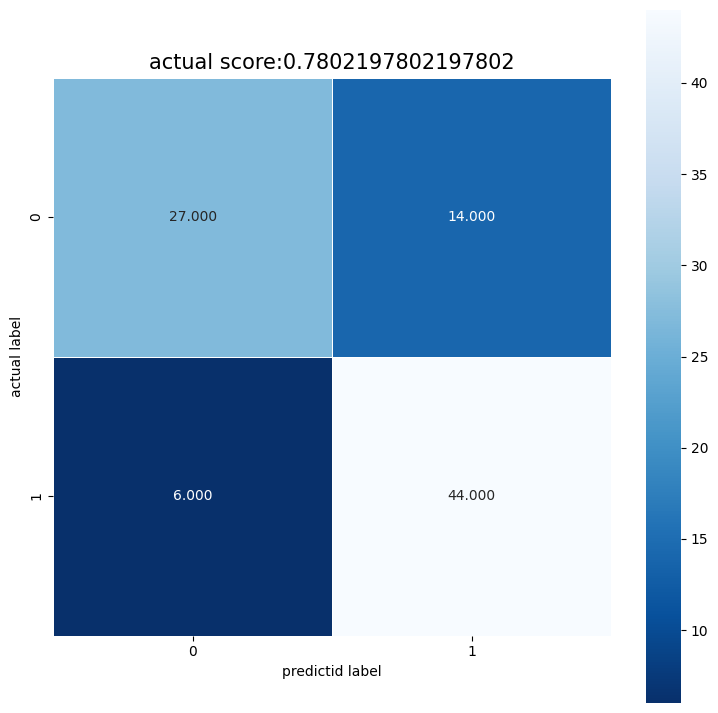

In [41]:
plt.figure(figsize=(9,9));
sns.heatmap(cm,annot=True,fmt=".3f",linewidths=0.5,square=True,cmap="Blues_r")
plt.ylabel("actual label")
plt.xlabel("predictid label")
all_sample_title="actual score:{0}".format(score)
plt.title(all_sample_title,size=15)